# Data Loading

In [1]:
#%pip install numpy>=2.1.0 scipy>=1.15.0 pandas>=2.2.3 scikit-learn>=1.6.0 imbalanced-learn>=0.13.0 xgboost>=2.1.1 shap>=0.46.0 missingno seaborn --quiet

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

In [3]:
df_employee_survey_data = pd.read_csv(Path("data/raw/employee_survey_data.csv"))
df_general_data = pd.read_csv(Path("data/raw/general_data.csv"))
df_in_time = pd.read_csv(Path("data/raw/in_time.csv"))
df_out_time = pd.read_csv(Path("data/raw/out_time.csv"))
df_manager_survey_data = pd.read_csv(Path("data/raw/manager_survey_data.csv"))

In [4]:
df = df_general_data.merge(df_employee_survey_data, on="EmployeeID") \
                    .merge(df_manager_survey_data, on="EmployeeID")

print(f"Shape: {df.shape}")
df.head()

Shape: (4410, 29)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,6,1,0,0,3.0,4.0,2.0,3,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,6.0,3,5,1,4,3.0,2.0,4.0,2,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,5.0,2,5,0,3,2.0,2.0,1.0,3,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,13.0,5,8,7,5,4.0,4.0,3.0,2,3
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,9.0,2,6,0,4,4.0,1.0,3.0,3,3


# Data View

In [5]:
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,6,1,0,0,3.0,4.0,2.0,3,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,6.0,3,5,1,4,3.0,2.0,4.0,2,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,5.0,2,5,0,3,2.0,2.0,1.0,3,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,13.0,5,8,7,5,4.0,4.0,3.0,2,3
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,9.0,2,6,0,4,4.0,1.0,3.0,3,3


In [6]:
df.describe(include='all')

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
count,4410.000000,4410,4410,4410,4410.000000,4410.000000,4410,4410.0,4410.000000,4410,...,4401.000000,4410.000000,4410.000000,4410.000000,4410.000000,4385.000000,4390.000000,4372.000000,4410.000000,4410.000000
unique,NaN,2,3,3,NaN,NaN,6,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3699,3129,2883,NaN,NaN,1818,NaN,NaN,2646,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,NaN,9.192517,2.912925,NaN,1.0,2205.500000,NaN,...,11.279936,2.799320,7.008163,2.187755,4.123129,2.723603,2.728246,2.761436,2.729932,3.153741
std,9.133301,NaN,NaN,NaN,8.105026,1.023933,NaN,0.0,1273.201673,NaN,...,7.782222,1.288978,6.125135,3.221699,3.567327,1.092756,1.101253,0.706245,0.711400,0.360742
min,18.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,1.0,1.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,30.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,1.0,1103.250000,NaN,...,6.000000,2.000000,3.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
50%,36.000000,NaN,NaN,NaN,7.000000,3.000000,NaN,1.0,2205.500000,NaN,...,10.000000,3.000000,5.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,43.000000,NaN,NaN,NaN,14.000000,4.000000,NaN,1.0,3307.750000,NaN,...,15.000000,3.000000,9.000000,3.000000,7.000000,4.000000,4.000000,3.000000,3.000000,3.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   str    
 2   BusinessTravel           4410 non-null   str    
 3   Department               4410 non-null   str    
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   str    
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   str    
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   str    
 12  MaritalStatus            4410 non-null   str    
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked       4391 non-n

# Data Cleaning

## Analyse des valeurs manquantes

Avant d'imputer, il est essentiel d'analyser le **pattern** des données manquantes. Dans notre contexte :
- Les données d'enquête (`EnvironmentSatisfaction`, `JobSatisfaction`, `WorkLifeBalance`) proviennent d'un questionnaire **non obligatoire**. Les NA ne sont donc pas aléatoires (MCAR) mais potentiellement liés à l'insatisfaction des employés (**MAR voire MNAR**) — un salarié mécontent est plus susceptible de ne pas répondre.
- Les données RH (`NumCompaniesWorked`, `TotalWorkingYears`) ont des NA probablement aléatoires (données non renseignées).

**Stratégie retenue :**
- Variables numériques RH → imputation par la **médiane** (robuste aux outliers)
- Variables d'enquête → imputation par la **médiane**, mais on crée un **flag binaire `_missing`** pour capturer le signal informatif de la non-réponse
- Variables catégorielles → imputation par le **mode**

In [8]:
import missingno as msno

# Visualisation du pattern de données manquantes
print("=== Valeurs manquantes par colonne ===")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing.sort_values(ascending=False))
print(f"\nTotal lignes : {len(df)}")

# Taux de non-réponse à l'enquête
survey_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']
for col in survey_cols:
    na_rate = df[col].isna().mean()
    print(f"{col} : {na_rate:.1%} de non-réponse")

=== Valeurs manquantes par colonne ===
WorkLifeBalance            38
EnvironmentSatisfaction    25
JobSatisfaction            20
NumCompaniesWorked         19
TotalWorkingYears           9
dtype: int64

Total lignes : 4410
EnvironmentSatisfaction : 0.6% de non-réponse
JobSatisfaction : 0.5% de non-réponse
WorkLifeBalance : 0.9% de non-réponse


In [9]:
# ─── Imputation avec flags pour les variables d'enquête ───────────────────────
# Les NA d'enquête sont potentiellement informatifs (MAR/MNAR) : on garde le signal

survey_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']
for col in survey_cols:
    df[f'{col}_missing'] = df[col].isna().astype(int)

# Imputation standard
def replace_missing_values(dataframe):
    for column in dataframe.columns:
        if dataframe[column].dtype in ['object', 'string']:
            dataframe[column] = dataframe[column].fillna(dataframe[column].mode()[0])
        else:
            dataframe[column] = dataframe[column].fillna(dataframe[column].median())
    return dataframe

df = replace_missing_values(df)
df_out_time = replace_missing_values(df_out_time)
df_in_time = replace_missing_values(df_in_time)

print("Imputation terminée ✓")
print(f"Flags de non-réponse ajoutés : {[c for c in df.columns if '_missing' in c]}")
print(f"Vérification NA restants : {df.isna().sum().sum()}")

Imputation terminée ✓
Flags de non-réponse ajoutés : ['EnvironmentSatisfaction_missing', 'JobSatisfaction_missing', 'WorkLifeBalance_missing']
Vérification NA restants : 0


## Check for duplicates

In [10]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Total rows: {len(df)}")

Duplicate rows: 0
Total rows: 4410


## Remove useless columns

In [11]:
num_yes = df['Over18'].value_counts().get('Y', 0)
print(f"Number of 'Yes' in 'Over18': {num_yes}")

num_no = df['Over18'].value_counts().get('N', 0)
print(f"Number of 'No' in 'Over18': {num_no}")

num_yes = df['EmployeeCount'].value_counts().get(1, 0)
print(f"Number of 'Yes' in 'EmployeeCount': {num_yes}")

num_no = df['EmployeeCount'].value_counts().get(0, 0)
print(f"Number of 'No' in 'EmployeeCount': {num_no}")

num_eight = df['StandardHours'].value_counts().get(8, 0)
print(f"Number of '8' in 'StandardHours': {num_eight}")

num_zero = df['StandardHours'].value_counts().get(0, 0)
print(f"Number of '0' in 'StandardHours': {num_zero}")


Number of 'Yes' in 'Over18': 4410
Number of 'No' in 'Over18': 0
Number of 'Yes' in 'EmployeeCount': 4410
Number of 'No' in 'EmployeeCount': 0
Number of '8' in 'StandardHours': 4410
Number of '0' in 'StandardHours': 0


Observation : we can see that “Over 18” and "EmployeeCount" columns contain only “Yes” entries, so we can delete them since they serve no purpose. Same for StandardHours with the value 8

In [12]:
df = df.drop(columns=['Over18', 'EmployeeCount', 'StandardHours'])

## Détection et traitement des outliers

Après détection via IQR, on prend des **décisions explicites** :
- **MonthlyIncome, TotalWorkingYears, YearsAtCompany** : outliers cohérents avec la réalité RH (directeurs seniors) → on **conserve** ces valeurs
- **NumCompaniesWorked** : valeurs extrêmes possibles mais rares → on **cappe** à la borne IQR supérieure (winsorization)
- **TrainingTimesLastYear** : quelques valeurs élevées → on **conserve** (plausible pour certains profils)

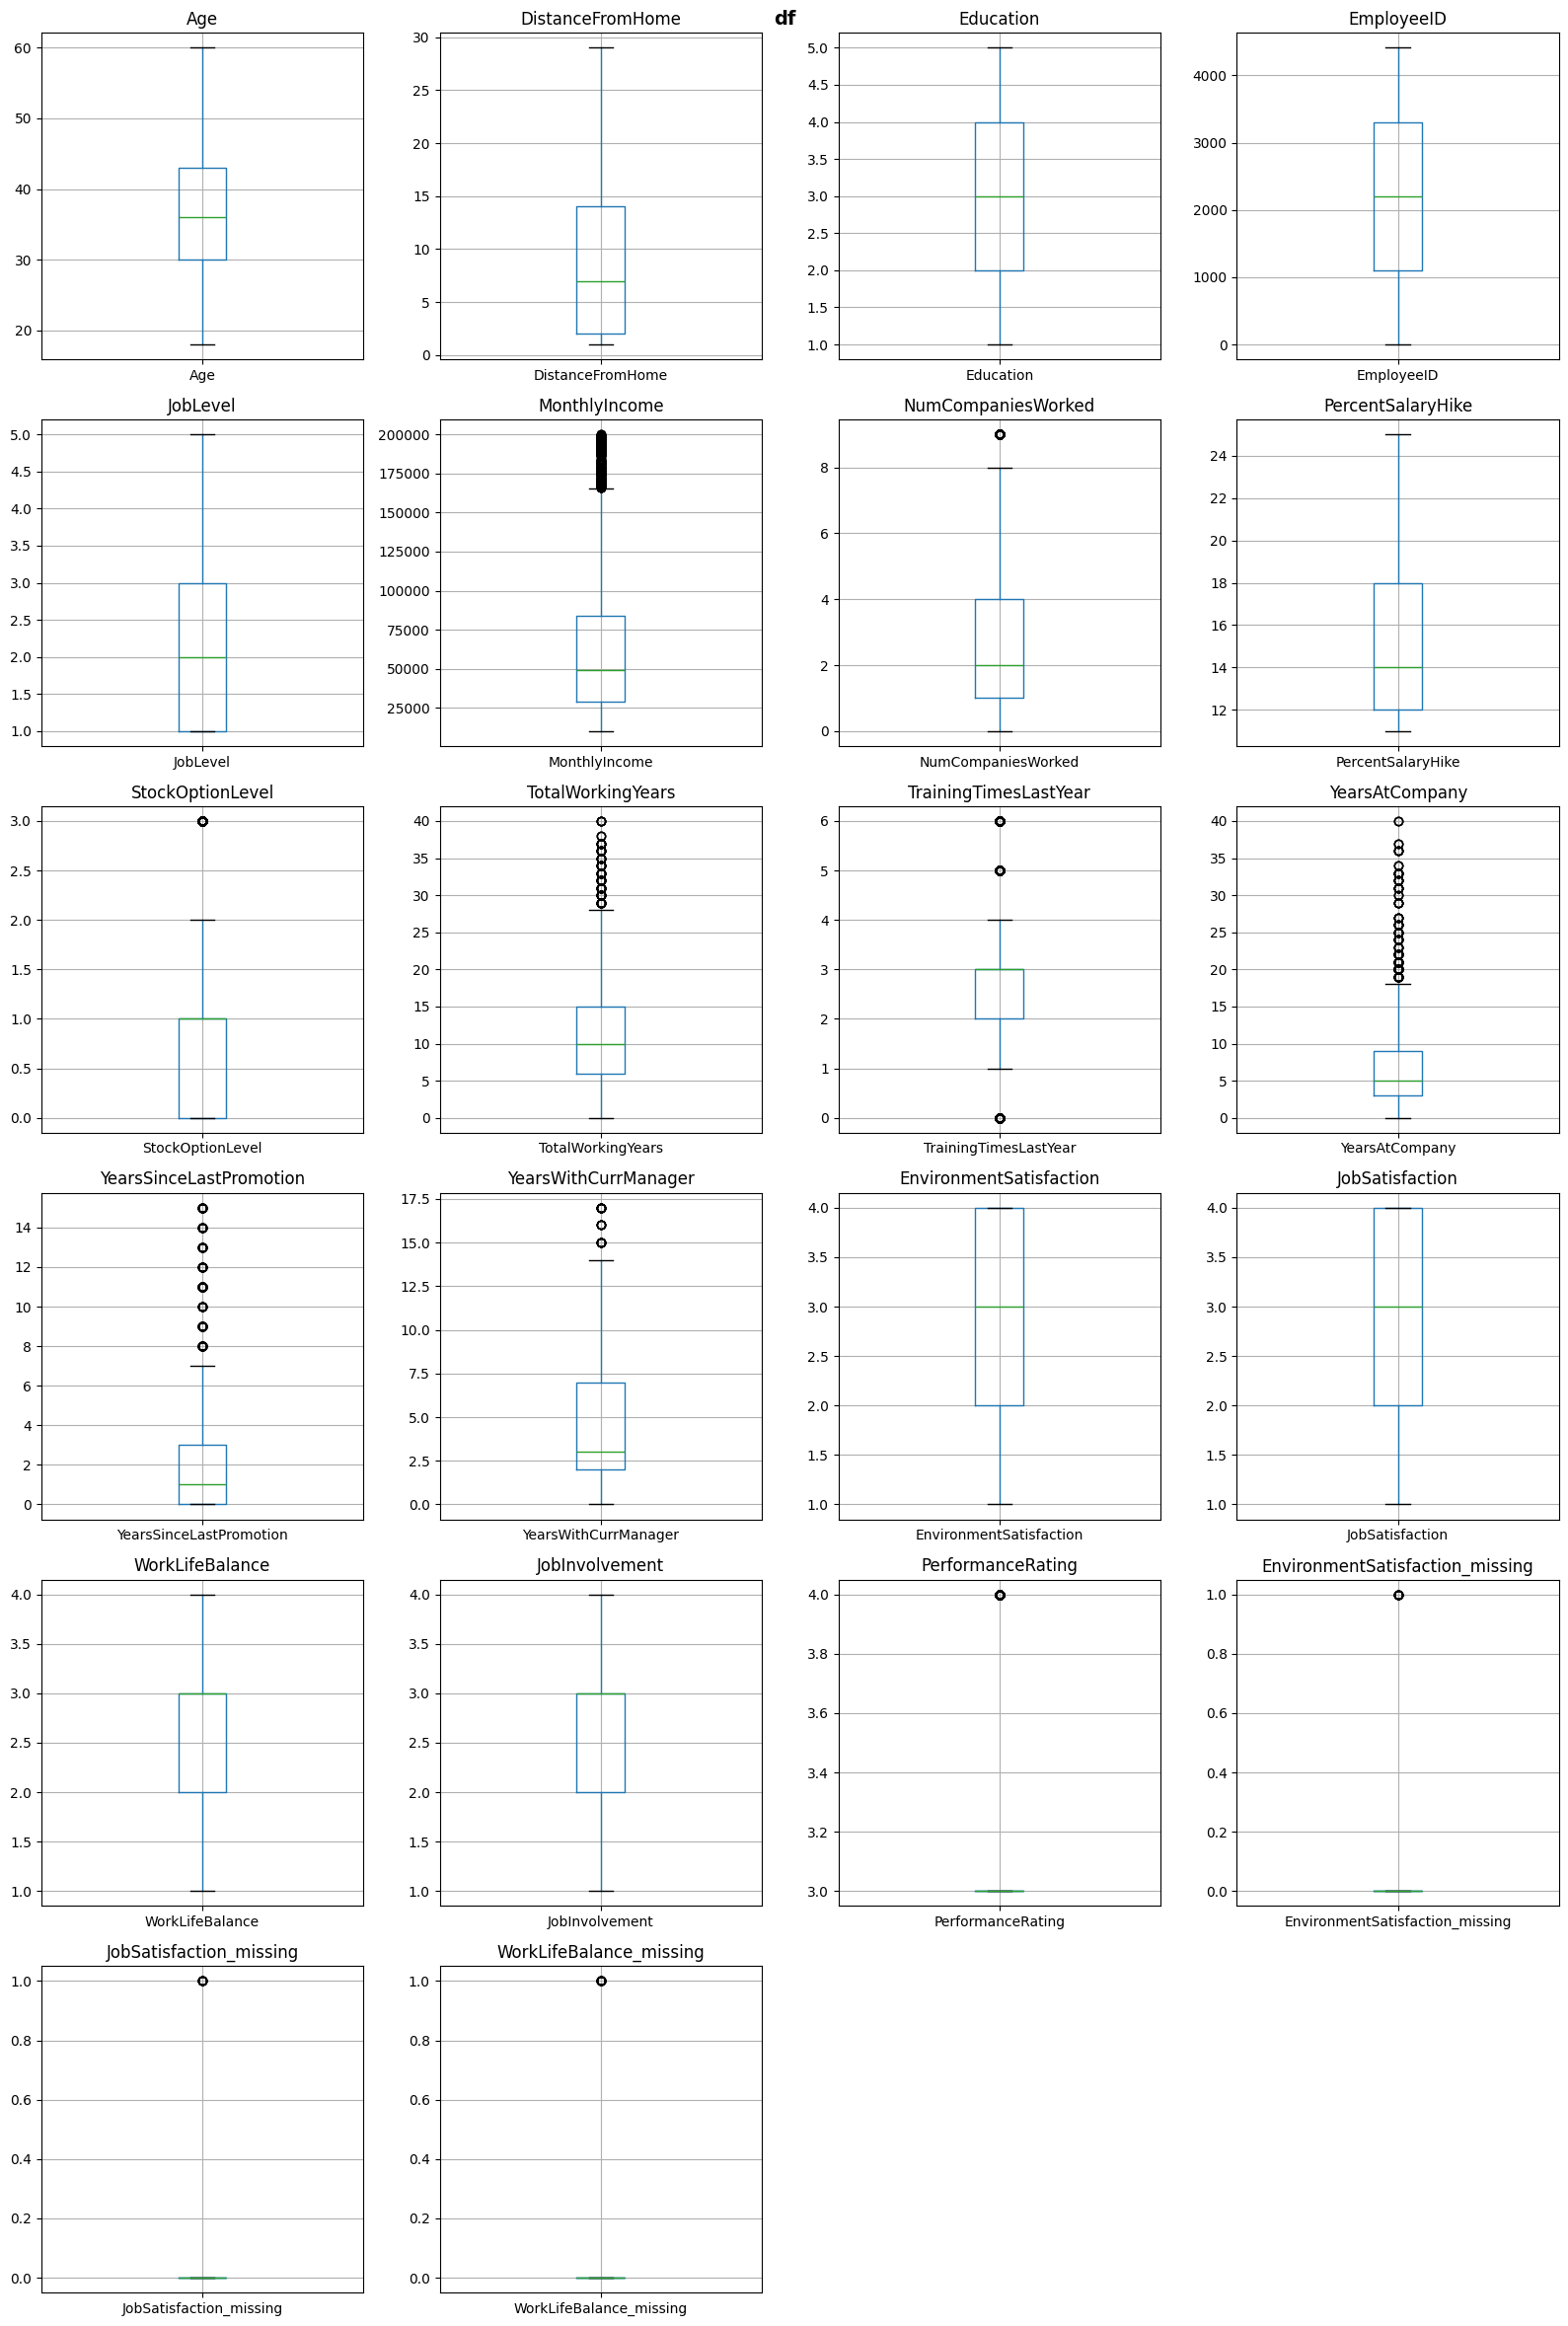

In [13]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns
n = len(num_cols)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()
for i, column in enumerate(num_cols):
    df.boxplot(column=[column], ax=axes[i])
    axes[i].set_title(column)
for i in range(n, len(axes)):
    axes[i].set_visible(False)
fig.suptitle("df", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [14]:
def detect_outliers(dataframe):
    outlier_report = {}
    for column in dataframe.select_dtypes(include="number").columns:
        Q1 = dataframe[column].quantile(0.25)
        Q3 = dataframe[column].quantile(0.75)
        IQR = Q3 - Q1
        n_outliers = ((dataframe[column] < Q1 - 1.5 * IQR) | (dataframe[column] > Q3 + 1.5 * IQR)).sum()
        if n_outliers > 0:
            outlier_report[column] = n_outliers
            print(f"{column}: {n_outliers} outliers ({n_outliers/len(dataframe):.1%})")
    return outlier_report

outlier_report = detect_outliers(df)

MonthlyIncome: 342 outliers (7.8%)
NumCompaniesWorked: 156 outliers (3.5%)
StockOptionLevel: 255 outliers (5.8%)
TotalWorkingYears: 189 outliers (4.3%)
TrainingTimesLastYear: 714 outliers (16.2%)
YearsAtCompany: 312 outliers (7.1%)
YearsSinceLastPromotion: 321 outliers (7.3%)
YearsWithCurrManager: 42 outliers (1.0%)
PerformanceRating: 678 outliers (15.4%)
EnvironmentSatisfaction_missing: 25 outliers (0.6%)
JobSatisfaction_missing: 20 outliers (0.5%)
WorkLifeBalance_missing: 38 outliers (0.9%)


In [15]:
# ─── Winsorization ciblée (capping des outliers extrêmes) ─────────────────────
# On cappe NumCompaniesWorked et YearsSinceLastPromotion à la borne IQR haute
# Les autres outliers sont conservés car cohérents avec le domaine métier

cols_to_cap = ['NumCompaniesWorked', 'YearsSinceLastPromotion']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    n_capped = (df[col] > upper_bound).sum()
    df[col] = df[col].clip(upper=upper_bound)
    print(f"{col} : {n_capped} valeurs cappées à {upper_bound:.1f}")

print("\nOutliers traités ✓ — les autres variables sont conservées (valeurs métier cohérentes)")

NumCompaniesWorked : 156 valeurs cappées à 8.5
YearsSinceLastPromotion : 321 valeurs cappées à 7.5

Outliers traités ✓ — les autres variables sont conservées (valeurs métier cohérentes)


## Feature Engineering (in_time / out_time)

In [16]:
# Convert timestamp columns to datetime
date_cols = [col for col in df_in_time.columns if col != "Unnamed: 0"]

for col in date_cols:
    df_in_time[col] = pd.to_datetime(df_in_time[col], errors="coerce")
    df_out_time[col] = pd.to_datetime(df_out_time[col], errors="coerce")

# Compute work duration in hours for each day
df_duration = df_out_time[date_cols] - df_in_time[date_cols]
df_duration = df_duration.apply(lambda x: x.dt.total_seconds() / 3600)

df_duration.head()

,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,2015-01-14,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,NaN,7.208333,7.189722,7.410833,7.006667,7.289722,7.484444,7.262778,7.831111,NaN,...,6.900000,7.339167,7.395833,6.504722,7.596389,NaN,7.773889,7.315000,7.778889,7.080278
1,NaN,8.109167,7.454722,6.697222,7.396944,7.416667,7.150833,7.611389,7.278889,NaN,...,7.903056,7.753889,7.712222,7.435556,5.978889,NaN,7.614722,7.982500,7.986111,8.227222
2,NaN,6.692500,7.265556,6.405278,6.765000,7.345000,6.861389,7.418611,6.999722,NaN,...,6.785833,7.163611,6.801667,6.730278,6.849722,NaN,7.023889,7.438889,7.538889,6.786389
3,NaN,7.338333,7.291944,6.943056,6.919444,6.850833,7.193056,6.998611,7.306389,NaN,...,7.629167,6.846667,7.326389,7.413611,7.085000,NaN,7.447222,7.416667,7.366389,7.133056
4,NaN,8.055556,7.988056,7.682500,7.806111,7.662222,7.721667,8.365000,8.257222,NaN,...,7.903611,7.665000,7.957500,7.786944,8.249444,NaN,7.662222,8.268611,7.953333,8.018056


In [17]:
# Extract features per employee
df_time_features = pd.DataFrame()
df_time_features["EmployeeID"] = df_in_time["Unnamed: 0"]

# Average work duration (hours/day)
df_time_features["AvgWorkHours"] = df_duration.mean(axis=1)

# Std deviation of work duration (regularity)
df_time_features["StdWorkHours"] = df_duration.std(axis=1)

# Number of absent days (NaT in in_time = absent)
df_time_features["AbsentDays"] = df_in_time[date_cols].isna().sum(axis=1)

# Average arrival hour
df_arrival = df_in_time[date_cols].apply(lambda x: x.dt.hour + x.dt.minute / 60)
df_time_features["AvgArrivalHour"] = df_arrival.mean(axis=1)

# Average departure hour
df_departure = df_out_time[date_cols].apply(lambda x: x.dt.hour + x.dt.minute / 60)
df_time_features["AvgDepartureHour"] = df_departure.mean(axis=1)

df_time_features.head()

,EmployeeID,AvgWorkHours,StdWorkHours,AbsentDays,AvgArrivalHour,AvgDepartureHour
0,1,7.332589,0.345296,12,9.990897,17.323762
1,2,7.673562,0.377188,12,9.977711,17.650000
2,3,7.009591,0.326156,12,10.012784,17.022624
3,4,7.184439,0.311909,12,9.970950,17.155154
4,5,7.989560,0.335775,12,9.988956,17.978581


In [18]:
# Merge time features into df (same row order, drop EmployeeID helper column)
df = pd.concat([df, df_time_features.drop(columns=["EmployeeID"])], axis=1)

print(f"Shape after merge: {df.shape}")
df[["AvgWorkHours", "StdWorkHours", "AbsentDays", "AvgArrivalHour", "AvgDepartureHour"]].describe()

Shape after merge: (4410, 34)


,AvgWorkHours,StdWorkHours,AbsentDays,AvgArrivalHour,AvgDepartureHour
count,4410.000000,4410.000000,4410.0,4410.000000,4410.000000
mean,7.660595,0.424194,12.0,9.988780,17.649339
std,1.283256,0.165437,0.0,0.017317,1.283760
min,5.983206,0.262225,12.0,9.927309,15.966934
25%,6.676053,0.325579,12.0,9.977376,16.660007
50%,7.373362,0.355332,12.0,9.989023,17.361044
75%,8.269605,0.442777,12.0,10.000067,18.257898
max,10.995263,1.190621,12.0,10.062584,21.001941


## Analyse temporelle des horaires de travail

Au-delà des moyennes, on analyse l'**évolution mensuelle** des heures travaillées pour détecter des tendances (surcharge progressive, désengagement...).

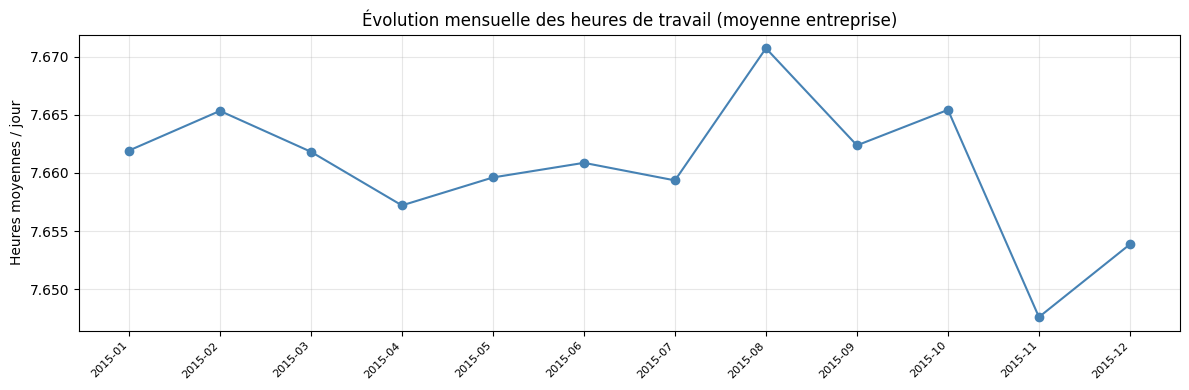

Feature 'WorkHoursTrend' ajoutée — tendance positive = heures en hausse sur l'année
Shape après ajout : (4410, 35)


In [19]:
# ─── Tendance mensuelle des heures travaillées ───────────────────────────────
# Regrouper les colonnes par mois
monthly_hours = {}
for col in date_cols:
    month = col[:7]  # "2015-01"
    if month not in monthly_hours:
        monthly_hours[month] = []
    monthly_hours[month].append(col)

# Calculer la durée moyenne par mois pour chaque employé
monthly_avg = pd.DataFrame()
for month, cols in sorted(monthly_hours.items()):
    monthly_avg[month] = df_duration[cols].mean(axis=1)

# Calculer la tendance (pente de régression linéaire) par employé
from scipy.stats import linregress
x_months = np.arange(monthly_avg.shape[1])

def compute_trend(row):
    valid = row.dropna()
    if len(valid) < 3:
        return 0.0
    slope, _, _, _, _ = linregress(np.arange(len(valid)), valid.values)
    return slope

df_time_features_extra = pd.DataFrame()
df_time_features_extra["WorkHoursTrend"] = monthly_avg.apply(compute_trend, axis=1)

# Tendance globale : visualisation
fig, ax = plt.subplots(figsize=(12, 4))
monthly_global = monthly_avg.mean()
ax.plot(range(len(monthly_global)), monthly_global.values, 'o-', color='steelblue')
ax.set_xticks(range(len(monthly_global)))
ax.set_xticklabels(monthly_global.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Heures moyennes / jour")
ax.set_title("Évolution mensuelle des heures de travail (moyenne entreprise)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Merger la tendance
df = pd.concat([df, df_time_features_extra.reset_index(drop=True)], axis=1)
print(f"Feature 'WorkHoursTrend' ajoutée — tendance positive = heures en hausse sur l'année")
print(f"Shape après ajout : {df.shape}")

## Encodage des variables catégorielles

> **Note méthodologique :** la standardisation (StandardScaler) sera effectuée **après** le train/test split pour éviter toute fuite de données (data leakage). On ne fait ici que l'encodage.

In [20]:
for col in df.select_dtypes(exclude="number").columns:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()}")

Attrition: 2 unique values -> <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
BusinessTravel: 3 unique values -> <ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str
Department: 3 unique values -> <ArrowStringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str
EducationField: 6 unique values -> <ArrowStringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str
Gender: 2 unique values -> <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
JobRole: 9 unique values -> <ArrowStringArray>
['Healthcare Representative',        'Research Scientist',
           'Sales Executive',           'Human Resources',
         'Research Director',     'Laboratory Technician',
    'Manufacturing Director',      'Sales Representative',
                   'Manager']
Length: 9, dtype: str
MaritalStatus: 3 unique values -> <Arro

In [21]:
# Label encoding for binary columns
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})

# Ordinal encoding for BusinessTravel (ordered)
travel_order = {"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2}
df["BusinessTravel"] = df["BusinessTravel"].map(travel_order)

# One-hot encoding for nominal columns (no inherent order)
df = pd.get_dummies(df, columns=["Department", "EducationField", "JobRole", "MaritalStatus"], dtype=int)

df.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,EmployeeID,Gender,JobLevel,MonthlyIncome,NumCompaniesWorked,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,51,0,1,6,2,1,0,1,131160,1.0,...,0,0,0,0,0,0,0,0,1,0
1,31,1,2,10,1,2,0,1,41890,0.0,...,0,0,0,0,1,0,0,0,0,1
2,32,0,2,17,4,3,1,4,193280,1.0,...,0,0,0,0,0,1,0,0,1,0
3,38,0,0,2,5,4,1,3,83210,3.0,...,0,0,0,0,0,0,0,0,1,0
4,32,0,1,10,1,5,1,1,23420,4.0,...,0,0,0,0,0,1,0,0,0,1


### Encoding Summary

**Label Encoding (binary):**
| Column | 0 | 1 |
|--------|---|---|
| Attrition | No | Yes |
| Gender | Female | Male |

**Ordinal Encoding (ordered):**
| Column | 0 | 1 | 2 |
|--------|---|---|---|
| BusinessTravel | Non-Travel | Travel_Rarely | Travel_Frequently |

**One-Hot Encoding (nominal):**
- **Department** → `Department_Human Resources`, `Department_Research & Development`, `Department_Sales`
- **EducationField** → `EducationField_Human Resources`, `EducationField_Life Sciences`, `EducationField_Marketing`, `EducationField_Medical`, `EducationField_Other`, `EducationField_Technical Degree`
- **JobRole** → `JobRole_Healthcare Representative`, `JobRole_Human Resources`, `JobRole_Laboratory Technician`, `JobRole_Manager`, `JobRole_Manufacturing Director`, `JobRole_Research Director`, `JobRole_Research Scientist`, `JobRole_Sales Executive`, `JobRole_Sales Representative`
- **MaritalStatus** → `MaritalStatus_Divorced`, `MaritalStatus_Married`, `MaritalStatus_Single`

# Exploratory Data Analysis (EDA)

## Target Distribution

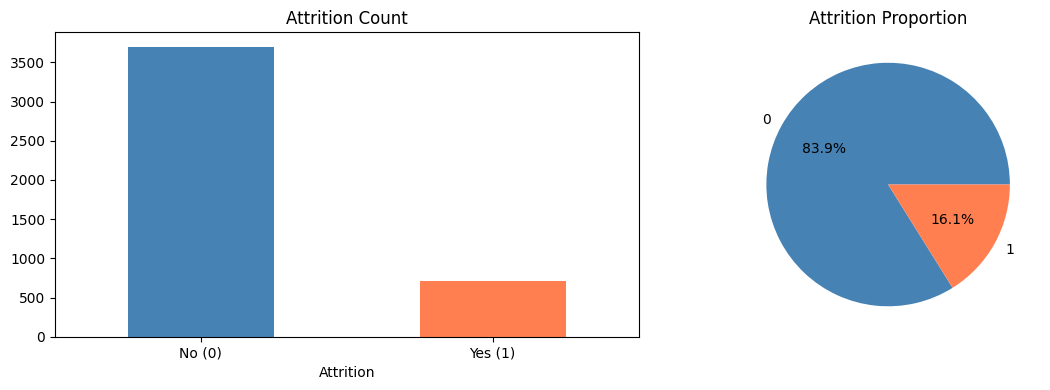

Class balance: {0: 3699, 1: 711}


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Attrition"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Attrition Count")
axes[0].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)

df["Attrition"].value_counts(normalize=True).plot(kind="pie", ax=axes[1], autopct="%.1f%%", colors=["steelblue", "coral"])
axes[1].set_title("Attrition Proportion")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(f"Class balance: {df['Attrition'].value_counts().to_dict()}")

## Correlation Matrix

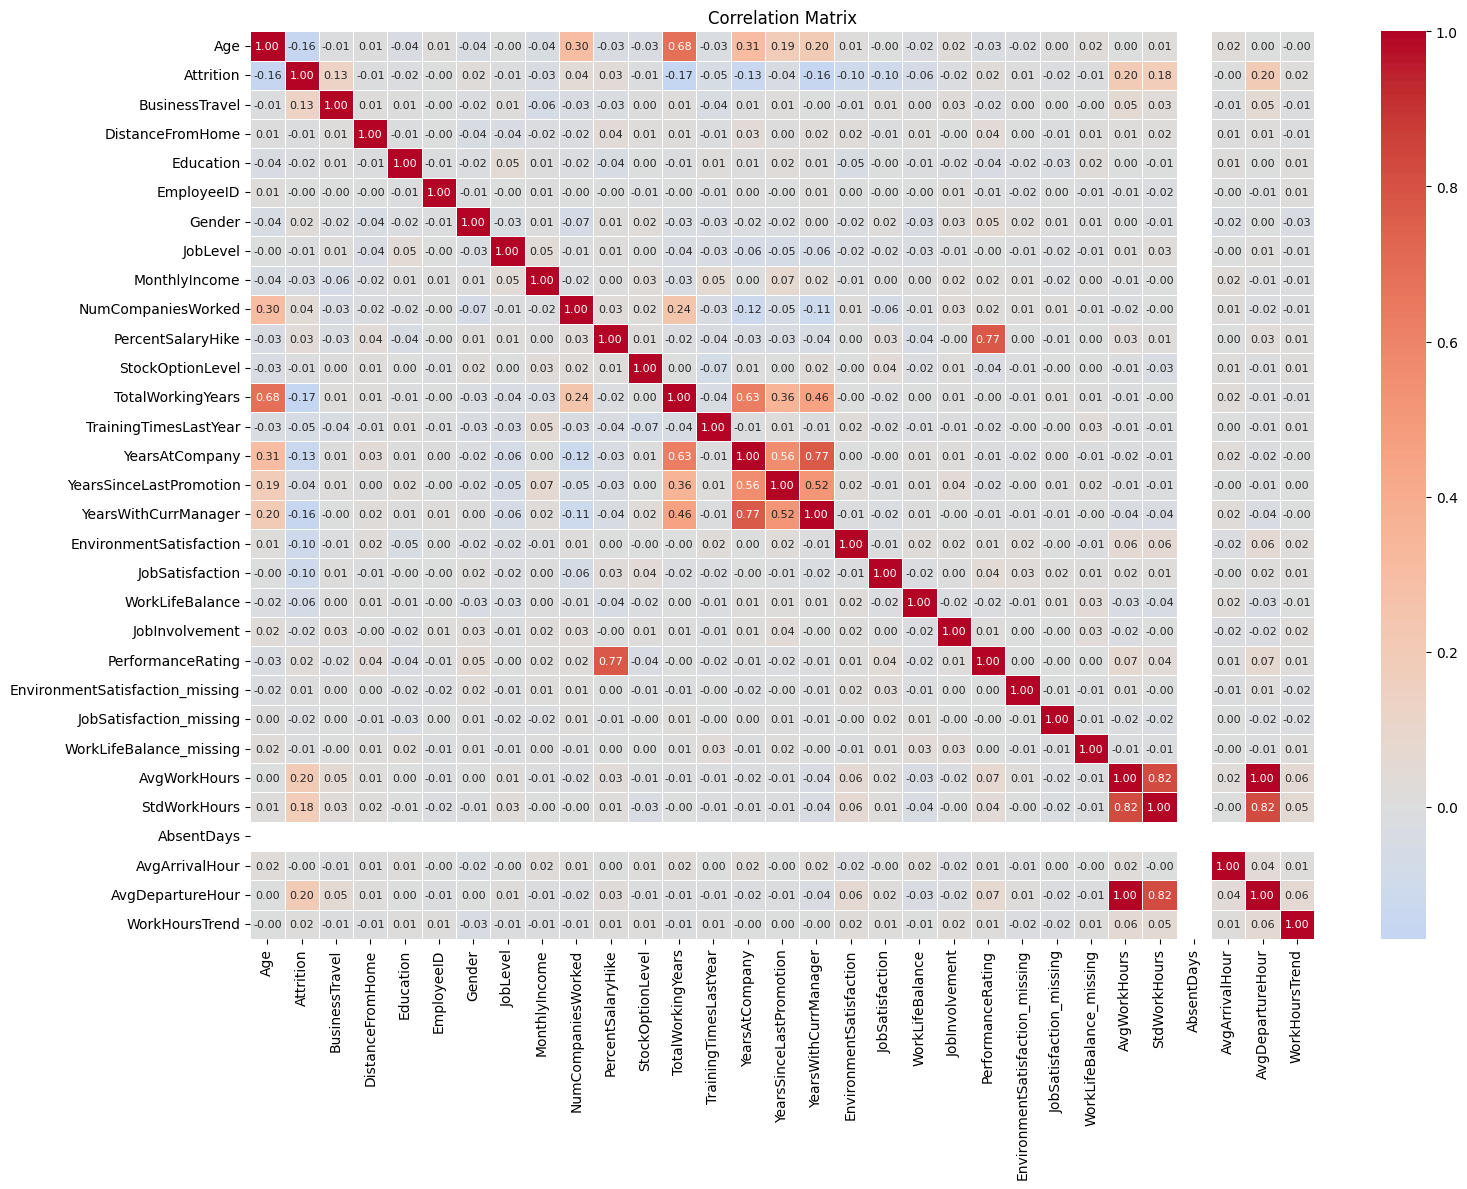

In [23]:
# Exclude one-hot encoded columns from correlation matrix
one_hot_prefixes = ("Department_", "EducationField_", "JobRole_", "MaritalStatus_")
cols_corr = [col for col in df.select_dtypes(include="number").columns if not col.startswith(one_hot_prefixes)]

plt.figure(figsize=(16, 12))
corr = df[cols_corr].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Top Correlations with Attrition

AvgWorkHours               0.201191
AvgDepartureHour           0.201097
StdWorkHours               0.183267
TotalWorkingYears         -0.170162
Age                       -0.159205
YearsWithCurrManager      -0.156199
YearsAtCompany            -0.134392
BusinessTravel             0.127006
JobSatisfaction           -0.103068
EnvironmentSatisfaction   -0.101625
WorkLifeBalance           -0.062975
TrainingTimesLastYear     -0.049431
NumCompaniesWorked         0.041444
YearsSinceLastPromotion   -0.037486
PercentSalaryHike          0.032533
Name: Attrition, dtype: float64


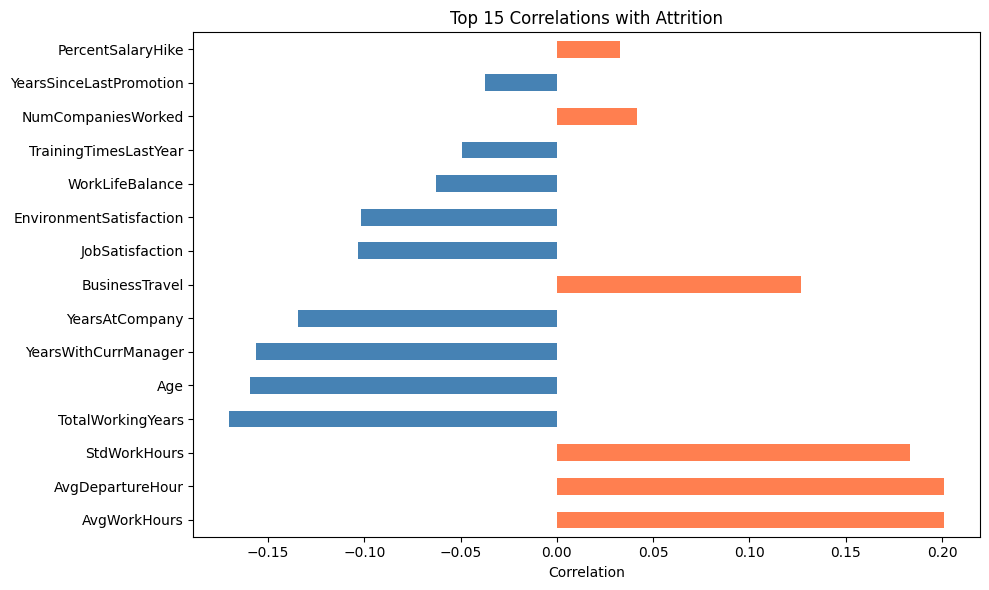

In [24]:
attrition_corr = corr["Attrition"].drop("Attrition").sort_values(key=abs, ascending=False)
print(attrition_corr.head(15))

plt.figure(figsize=(10, 6))
attrition_corr.head(15).plot(kind="barh", color=["coral" if x > 0 else "steelblue" for x in attrition_corr.head(15)])
plt.title("Top 15 Correlations with Attrition")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

## Key Feature Distributions by Attrition

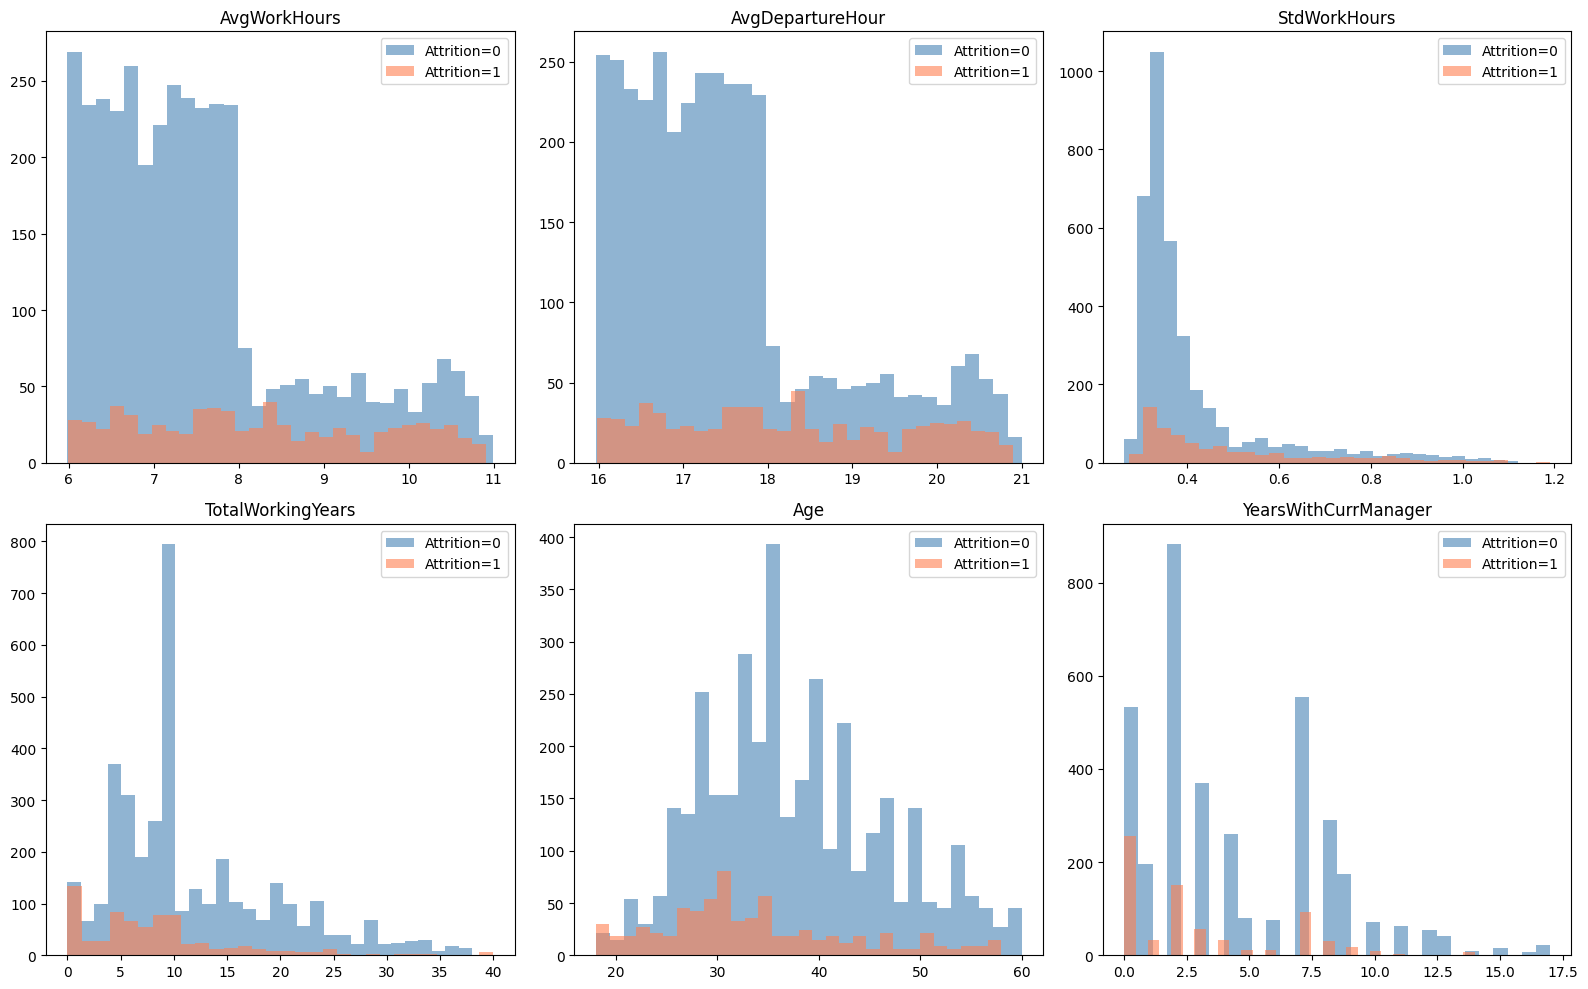

In [25]:
top_features = attrition_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    for label, color in [(0, "steelblue"), (1, "coral")]:
        axes[i].hist(df[df["Attrition"] == label][feature], bins=30, alpha=0.6, label=f"Attrition={label}", color=color)
    axes[i].set_title(feature)
    axes[i].legend()

plt.tight_layout()
plt.show()

# Modélisation — Prédiction de l'attrition

## 1. Préparation des données

### 1.1 Séparation X / y et train/test split

Notre target est **déséquilibrée** (~84% No / ~16% Yes). Stratégies mises en place :
- `stratify=y` dans le split → proportions identiques train/test
- `class_weight='balanced'` dans les modèles compatibles
- **SMOTE** testé comme alternative au rééquilibrage par pondération

In [26]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    RandomizedSearchCV, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb

In [27]:
# ─── Séparation X / y ─────────────────────────────────────────────────────────
TARGET = "Attrition"
id_cols = [c for c in df.columns if "EmployeeID" in c]

X = df.drop(columns=[TARGET] + id_cols)
y = df[TARGET]

print(f"Features : {X.shape[1]} colonnes | Observations : {X.shape[0]} lignes")

# ─── Train / Test split stratifié ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Attrition dans train : {y_train.mean():.1%} | dans test : {y_test.mean():.1%}")

Features : 50 colonnes | Observations : 4410 lignes

Train : 3528 lignes | Test : 882 lignes
Attrition dans train : 16.1% | dans test : 16.1%


### 1.2 Standardisation (sans fuite de données)

Le `StandardScaler` est **fitté uniquement sur le train** puis appliqué au test. C'est une correction critique par rapport à la version précédente où le scaler était fitté sur l'ensemble du dataset, ce qui introduisait une fuite d'information du test vers l'entraînement.

In [28]:
# ─── Standardisation CORRECTE : fit sur train, transform sur test ─────────────
cols_to_scale = X_train.select_dtypes(include='number').columns.tolist()
# Exclure les colonnes binaires (one-hot, flags) du scaling
binary_cols = [c for c in cols_to_scale if X_train[c].nunique() <= 2]
cols_to_scale = [c for c in cols_to_scale if c not in binary_cols]

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])   # fit + transform
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])        # transform ONLY

print(f"Scaling appliqué sur {len(cols_to_scale)} colonnes numériques (hors binaires)")
print("⚠ Scaler fitté sur le TRAIN uniquement → pas de data leakage")

Scaling appliqué sur 23 colonnes numériques (hors binaires)
⚠ Scaler fitté sur le TRAIN uniquement → pas de data leakage


### 1.3 Gestion du déséquilibre : SMOTE vs class_weight

On compare deux approches pour traiter le déséquilibre des classes :
1. **class_weight='balanced'** : pondère la loss par l'inverse de la fréquence de chaque classe
2. **SMOTE** : génère des exemples synthétiques de la classe minoritaire par interpolation

> **SMOTE est appliqué uniquement sur le train** pour éviter la fuite de données.

In [29]:
# ─── Application de SMOTE sur le train ────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE : {y_train.value_counts().to_dict()}")
print(f"Après SMOTE  : {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"\nLe train passe de {len(X_train)} à {len(X_train_smote)} observations")

Avant SMOTE : {0: 2959, 1: 569}
Après SMOTE  : {0: 2959, 1: 2959}

Le train passe de 3528 à 5918 observations


## 2. Modèle 1 : Random Forest

**Fonctionnement :** agrégation de N arbres de décision entraînés sur des sous-échantillons aléatoires des données et des features → vote majoritaire final.

**Paramètres clés :**
- `n_estimators` : nombre d'arbres
- `max_depth` : profondeur max → régularisation
- `class_weight='balanced'` : compense le déséquilibre de classes

In [30]:
# ─── Entraînement Random Forest ───────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest entraîné ✓")
print(classification_report(y_test, y_pred_rf, target_names=["No Attrition", "Attrition"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest entraîné ✓
              precision    recall  f1-score   support

No Attrition       0.96      0.96      0.96       740
   Attrition       0.81      0.77      0.79       142

    accuracy                           0.93       882
   macro avg       0.88      0.87      0.88       882
weighted avg       0.93      0.93      0.93       882

AUC-ROC : 0.9722


## 3. Modèle 2 : Régression Logistique

### Rappel théorique

La régression logistique modélise la probabilité d'un événement binaire via la fonction sigmoïde :

$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \ldots + \beta_n x_n)}}$$

La fonction de coût minimisée est la **binary cross-entropy** :

$$J(\beta) = - \frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

**Avantages pour ce projet :**
- Interprétabilité directe des coefficients (chaque $\beta$ quantifie l'effet de la feature)
- Probabilités naturellement calibrées
- Modèle de référence (baseline) rapide et fiable

In [31]:
# ─── Entraînement Régression Logistique ───────────────────────────────────────
log_reg = LogisticRegression(
    max_iter=1000, class_weight='balanced',
    solver='lbfgs', random_state=42
)
log_reg.fit(X_train, y_train)
y_pred_lr  = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("Régression Logistique entraînée ✓")
print(classification_report(y_test, y_pred_lr, target_names=["No Attrition", "Attrition"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.4f}")

Régression Logistique entraînée ✓
              precision    recall  f1-score   support

No Attrition       0.94      0.78      0.85       740
   Attrition       0.39      0.73      0.51       142

    accuracy                           0.77       882
   macro avg       0.66      0.76      0.68       882
weighted avg       0.85      0.77      0.80       882

AUC-ROC : 0.8087


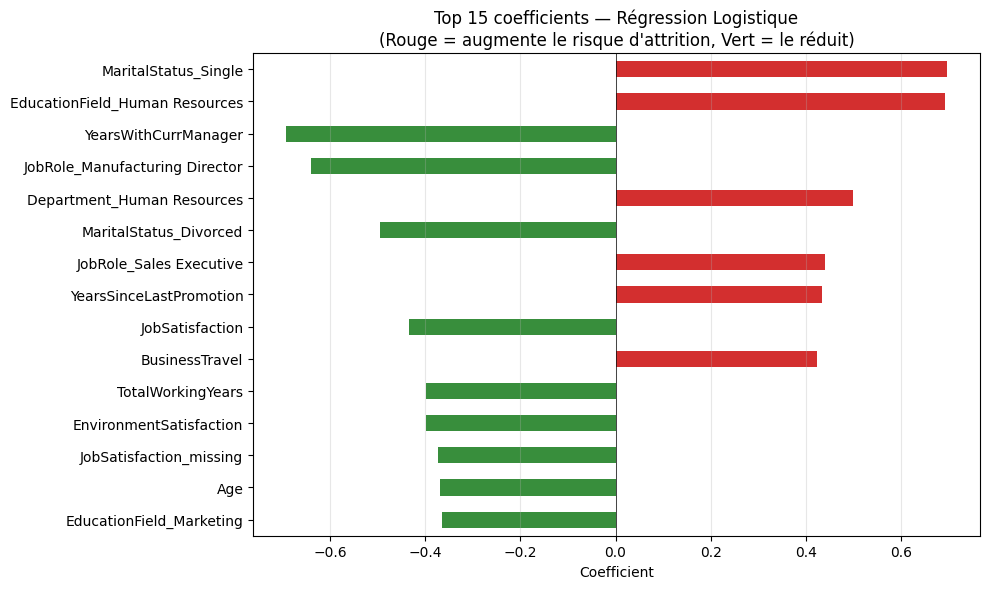

In [32]:
# ─── Coefficients de la Régression Logistique ─────────────────────────────────
coef_lr = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

top_n = 15
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d32f2f' if v > 0 else '#388e3c' for v in coef_lr.head(top_n)]
coef_lr.head(top_n).plot(kind='barh', ax=ax, color=colors)
ax.invert_yaxis()
ax.set_title(f"Top {top_n} coefficients — Régression Logistique\n(Rouge = augmente le risque d'attrition, Vert = le réduit)")
ax.set_xlabel("Coefficient")
ax.axvline(0, color='k', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Modèle 3 : XGBoost

**Pourquoi XGBoost plutôt que le Perceptron ?**
Le Perceptron est un modèle historique qui ne produit pas de probabilités et dont les performances sont généralement inférieures sur des données tabulaires. XGBoost est l'état de l'art pour la classification tabulaire :
- Implémentation optimisée du gradient boosting (parallélisation, cache-aware)
- Régularisation L1/L2 native (évite le surapprentissage)
- Gestion native des valeurs manquantes
- `scale_pos_weight` pour le déséquilibre de classes

### Rappel : Gradient Boosting optimisé

XGBoost optimise une **fonction objectif régularisée** :

$$\mathcal{L} = \sum_{i} l(y_i, \hat{y}_i) + \sum_{k} \Omega(f_k)$$

Où $\Omega(f) = \gamma T + \frac{1}{2}\lambda ||w||^2$ pénalise la complexité des arbres (nombre de feuilles $T$ et poids $w$).

In [33]:
# ─── Entraînement XGBoost ─────────────────────────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    reg_alpha=0.1,      # Régularisation L1
    reg_lambda=1.0,      # Régularisation L2
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost entraîné ✓")
print(classification_report(y_test, y_pred_xgb, target_names=["No Attrition", "Attrition"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost entraîné ✓
              precision    recall  f1-score   support

No Attrition       0.99      0.96      0.97       740
   Attrition       0.81      0.94      0.87       142

    accuracy                           0.95       882
   macro avg       0.90      0.95      0.92       882
weighted avg       0.96      0.95      0.96       882

AUC-ROC : 0.9856


## 5. Modèle 4 : Random Forest + SMOTE

Pour comparer l'impact du rééchantillonnage, on entraîne un Random Forest sur les données **SMOTE-augmentées** au lieu d'utiliser `class_weight='balanced'`.

In [34]:
# ─── Random Forest avec SMOTE ─────────────────────────────────────────────────
rf_smote = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    random_state=42, n_jobs=-1
    # Pas de class_weight='balanced' ici : SMOTE s'en charge
)

rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote  = rf_smote.predict(X_test)
y_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

print("Random Forest + SMOTE entraîné ✓")
print(classification_report(y_test, y_pred_smote, target_names=["No Attrition", "Attrition"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_smote):.4f}")

Random Forest + SMOTE entraîné ✓
              precision    recall  f1-score   support

No Attrition       0.96      0.97      0.96       740
   Attrition       0.83      0.77      0.80       142

    accuracy                           0.94       882
   macro avg       0.89      0.87      0.88       882
weighted avg       0.94      0.94      0.94       882

AUC-ROC : 0.9727


### Comparaison class_weight vs SMOTE

In [35]:
# ─── Impact de SMOTE vs class_weight ──────────────────────────────────────────
print("Comparaison sur le Random Forest :")
print(f"  class_weight='balanced' → F1={f1_score(y_test, y_pred_rf):.4f} | AUC={roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"  SMOTE                   → F1={f1_score(y_test, y_pred_smote):.4f} | AUC={roc_auc_score(y_test, y_proba_smote):.4f}")
print()
if roc_auc_score(y_test, y_proba_rf) >= roc_auc_score(y_test, y_proba_smote):
    print("→ class_weight='balanced' performe mieux ou égal à SMOTE sur ce dataset.")
    print("  Ce n'est pas surprenant : SMOTE peut introduire du bruit en interpolant")
    print("  dans des zones de décision ambiguës.")
else:
    print("→ SMOTE apporte un gain. L'enrichissement synthétique de la classe minoritaire")
    print("  aide le modèle à mieux apprendre la frontière de décision.")

Comparaison sur le Random Forest :
  class_weight='balanced' → F1=0.7914 | AUC=0.9722
  SMOTE                   → F1=0.7985 | AUC=0.9727

→ SMOTE apporte un gain. L'enrichissement synthétique de la classe minoritaire
  aide le modèle à mieux apprendre la frontière de décision.


## 6. Comparaison des 4 modèles

### 6.1 Courbes ROC et Précision-Rappel

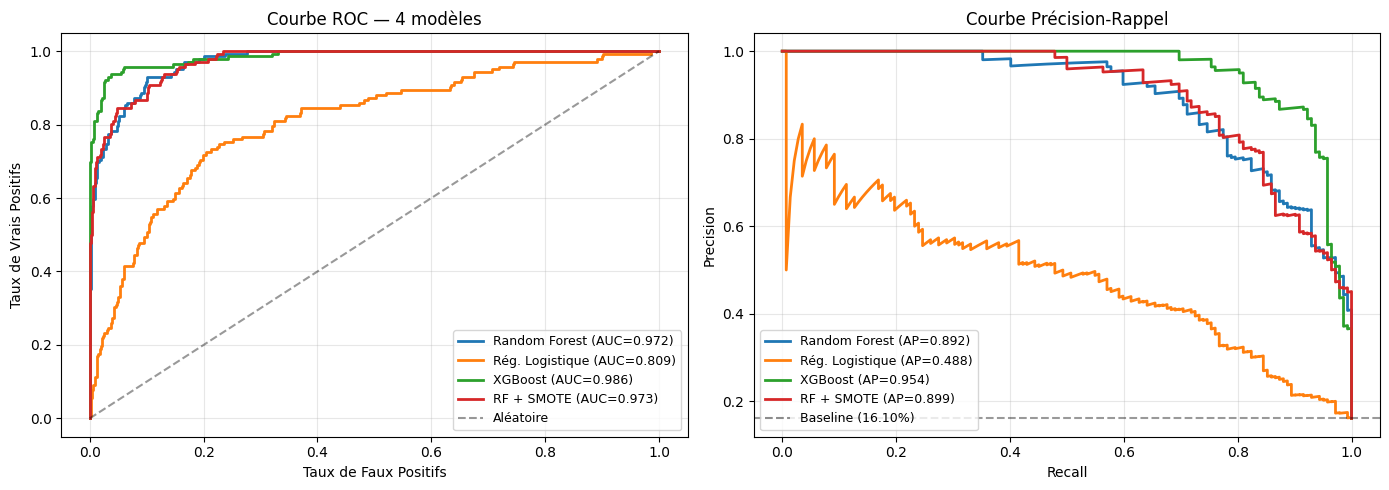

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_scores = [
    ("Random Forest",         y_proba_rf),
    ("Rég. Logistique",       y_proba_lr),
    ("XGBoost",               y_proba_xgb),
    ("RF + SMOTE",            y_proba_smote),
]

# Courbe ROC
ax = axes[0]
for name, y_proba in model_scores:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label="Aléatoire")
ax.set_xlabel("Taux de Faux Positifs")
ax.set_ylabel("Taux de Vrais Positifs")
ax.set_title("Courbe ROC — 4 modèles")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Courbe Précision-Rappel
ax = axes[1]
for name, y_proba in model_scores:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})", linewidth=2)
baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', alpha=0.4, label=f"Baseline ({baseline:.2%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Courbe Précision-Rappel")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Tableau comparatif

In [37]:
results = []
for name, y_pred, y_proba in [
    ("Random Forest",         y_pred_rf,    y_proba_rf),
    ("Rég. Logistique",       y_pred_lr,    y_proba_lr),
    ("XGBoost",               y_pred_xgb,   y_proba_xgb),
    ("RF + SMOTE",            y_pred_smote, y_proba_smote),
]:
    results.append({
        "Modèle":    name,
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1-Score":  f1_score(y_test, y_pred),
        "AUC-ROC":   roc_auc_score(y_test, y_proba),
        "Avg Prec":  average_precision_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Modèle").round(4)
print(results_df.to_string())
print()
print(f"▸ Meilleur AUC-ROC  : {results_df['AUC-ROC'].idxmax()}")
print(f"▸ Meilleur F1-Score : {results_df['F1-Score'].idxmax()}")

                 Precision  Recall  F1-Score  AUC-ROC  Avg Prec
Modèle                                                         
Random Forest       0.8088  0.7746    0.7914   0.9722    0.8924
Rég. Logistique     0.3895  0.7324    0.5086   0.8087    0.4875
XGBoost             0.8110  0.9366    0.8693   0.9856    0.9540
RF + SMOTE          0.8321  0.7676    0.7985   0.9727    0.8989

▸ Meilleur AUC-ROC  : XGBoost
▸ Meilleur F1-Score : XGBoost


### 6.3 Validation croisée stratifiée

In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Validation croisée 5-fold (stratifiée)\n")

cv_results = {}
for name, model in [
    ("Random Forest",    rf_model),
    ("Rég. Logistique",  log_reg),
    ("XGBoost",          xgb_model),
]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}")
    print(f"  AUC-ROC par fold : {np.round(scores, 4)}")
    print(f"  Moyenne : {scores.mean():.4f} ± {scores.std():.4f}")
    print()

Validation croisée 5-fold (stratifiée)

Random Forest
  AUC-ROC par fold : [0.9748 0.9601 0.9774 0.9744 0.9672]
  Moyenne : 0.9708 ± 0.0063

Rég. Logistique
  AUC-ROC par fold : [0.8079 0.7877 0.8044 0.81   0.7605]
  Moyenne : 0.7941 ± 0.0186

XGBoost
  AUC-ROC par fold : [0.9864 0.9862 0.9776 0.9902 0.9802]
  Moyenne : 0.9841 ± 0.0046



## 7. Optimisation des hyperparamètres

On utilise **RandomizedSearchCV** sur XGBoost (plus de paramètres à explorer, plus efficace que GridSearch exhaustif) et **GridSearchCV** sur le Random Forest. On optimise sur le **F1-Score** (pas l'accuracy, trompeuse avec des classes déséquilibrées).

In [39]:
import gc
from scipy.stats import randint, uniform

# 1. Libérer la mémoire avant de lancer le gros calcul
gc.collect()

# 2. Configuration de la recherche
param_dist_xgb = {
    'n_estimators':      randint(100, 500), 
    'max_depth':         randint(3, 8),    
    'learning_rate':     uniform(0.01, 0.1),
    'subsample':         uniform(0.7, 0.3),
    'colsample_bytree':  uniform(0.7, 0.3),
    'reg_alpha':         uniform(0, 0.5),
    'reg_lambda':        uniform(0.5, 1.5),
    'min_child_weight':  randint(1, 7),
}

random_search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=scale_pos,
        random_state=42, 
        eval_metric='logloss', 
        n_jobs=1  # IMPORTANT : On dit à l'arbre de ne pas se paralléliser lui-même...
    ),
    param_dist_xgb,
    n_iter=50,    
    cv=StratifiedKFold(5, shuffle=True, random_state=42), 
    scoring='f1',
    random_state=42,
    n_jobs=2,     # ...car c'est la recherche globale qui va utiliser 2 cœurs max.
    verbose=1
)

# Lancement de l'entraînement
try:
    random_search_xgb.fit(X_train, y_train)
    print(f"\n✓ Meilleurs paramètres XGBoost : {random_search_xgb.best_params_}")
    print(f"✓ Meilleur F1 en CV : {random_search_xgb.best_score_:.4f}")
except MemoryError:
    print("Erreur : Toujours pas assez de RAM. Essayez de mettre n_jobs=1 partout.")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✓ Meilleurs paramètres XGBoost : {'colsample_bytree': np.float64(0.7015554588321959), 'learning_rate': np.float64(0.0727894414948636), 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 363, 'reg_alpha': np.float64(0.3509834386288517), 'reg_lambda': np.float64(1.6936890041541517), 'subsample': np.float64(0.9670016025452699)}
✓ Meilleur F1 en CV : 0.9254


In [40]:
# ─── GridSearch sur Random Forest ─────────────────────────────────────────────
param_grid_rf = {
    'n_estimators':     [100, 300, 500],
    'max_depth':        [5, 10, 15, None],
    'min_samples_leaf': [3, 5, 10],
    'max_features':     ['sqrt', 'log2', 0.3],
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print(f"\n✓ Meilleurs paramètres RF : {grid_search_rf.best_params_}")
print(f"✓ Meilleur F1 en CV : {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

✓ Meilleurs paramètres RF : {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 3, 'n_estimators': 100}
✓ Meilleur F1 en CV : 0.8426


In [41]:
# ─── Évaluation des modèles optimisés ─────────────────────────────────────────
best_xgb = random_search_xgb.best_estimator_
best_rf  = grid_search_rf.best_estimator_

print("=" * 60)
for name, model in [("RF optimisé", best_rf), ("XGBoost optimisé", best_xgb)]:
    y_p = model.predict(X_test)
    y_pr = model.predict_proba(X_test)[:, 1]
    print(f"\n{name}")
    print(classification_report(y_test, y_p, target_names=["No Attrition", "Attrition"]))
    print(f"AUC-ROC : {roc_auc_score(y_test, y_pr):.4f} | F1 : {f1_score(y_test, y_p):.4f}")
    print("-" * 60)

# Sélection du meilleur modèle final
best_model_name = "XGBoost optimisé"
best_model = best_xgb
y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = best_model.predict(X_test)

auc_rf_opt = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])
auc_xgb_opt = roc_auc_score(y_test, y_proba_best)

if auc_rf_opt > auc_xgb_opt:
    best_model_name = "RF optimisé"
    best_model = best_rf
    y_proba_best = best_model.predict_proba(X_test)[:, 1]
    y_pred_best = best_model.predict(X_test)

print(f"\n★ Modèle retenu : {best_model_name} (AUC-ROC = {roc_auc_score(y_test, y_proba_best):.4f})")


RF optimisé
              precision    recall  f1-score   support

No Attrition       0.97      1.00      0.98       740
   Attrition       0.98      0.85      0.91       142

    accuracy                           0.97       882
   macro avg       0.97      0.92      0.94       882
weighted avg       0.97      0.97      0.97       882

AUC-ROC : 0.9883 | F1 : 0.9057
------------------------------------------------------------

XGBoost optimisé
              precision    recall  f1-score   support

No Attrition       1.00      1.00      1.00       740
   Attrition       1.00      0.98      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882

AUC-ROC : 0.9921 | F1 : 0.9893
------------------------------------------------------------

★ Modèle retenu : XGBoost optimisé (AUC-ROC = 0.9921)


## 8. Interprétabilité — SHAP Values

L'importance Gini (utilisée dans les Random Forests) est **biaisée** : elle favorise les variables à haute cardinalité. Les **SHAP values** (SHapley Additive exPlanations) offrent une interprétabilité plus fiable car :
- Elles mesurent la **contribution marginale** de chaque feature à chaque prédiction individuelle
- Elles sont théoriquement fondées (valeurs de Shapley issues de la théorie des jeux)
- Elles permettent de voir l'**impact directionnel** (augmente ou diminue le risque)

In [42]:
import shap

# ─── SHAP TreeExplainer (optimisé pour les modèles à arbres) ─────────────────
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Pour XGBoost, shap_values est directement un array
# Pour RF, c'est une liste [class_0, class_1] → on prend class_1
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f"SHAP values calculées pour {X_test.shape[0]} observations × {X_test.shape[1]} features")

SHAP values calculées pour 882 observations × 50 features


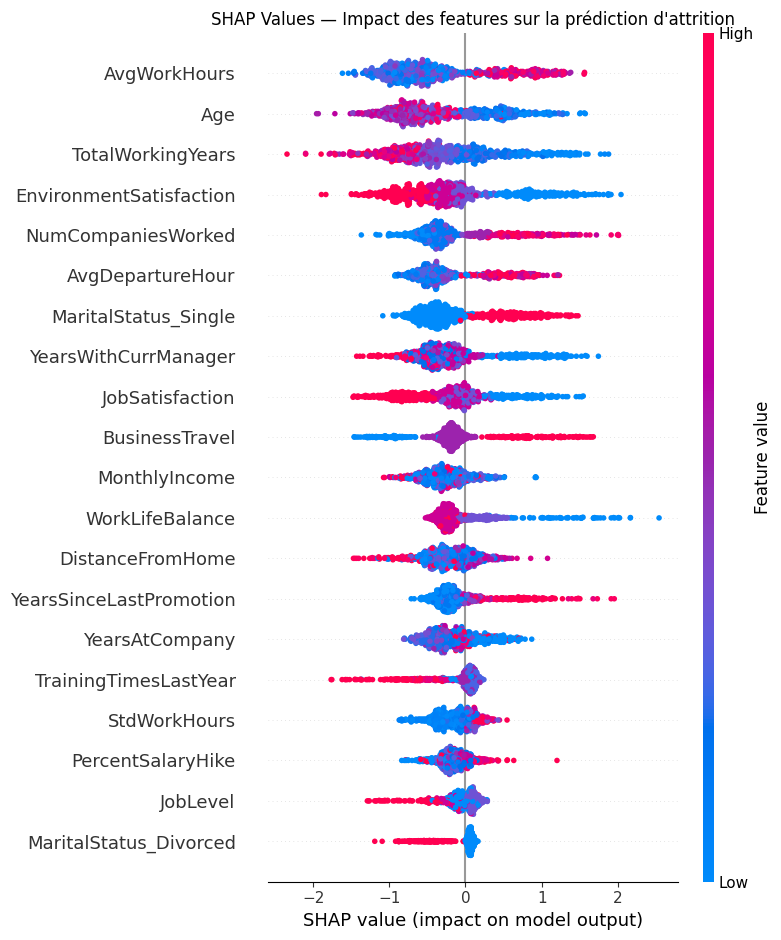

In [43]:
# ─── SHAP Summary Plot (beeswarm) ─────────────────────────────────────────────
# Chaque point = un employé. Couleur = valeur haute (rouge) ou basse (bleu) de la feature.
# Position = impact sur la prédiction d'attrition.

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test, max_display=20, show=False)
plt.title("SHAP Values — Impact des features sur la prédiction d'attrition")
plt.tight_layout()
plt.show()

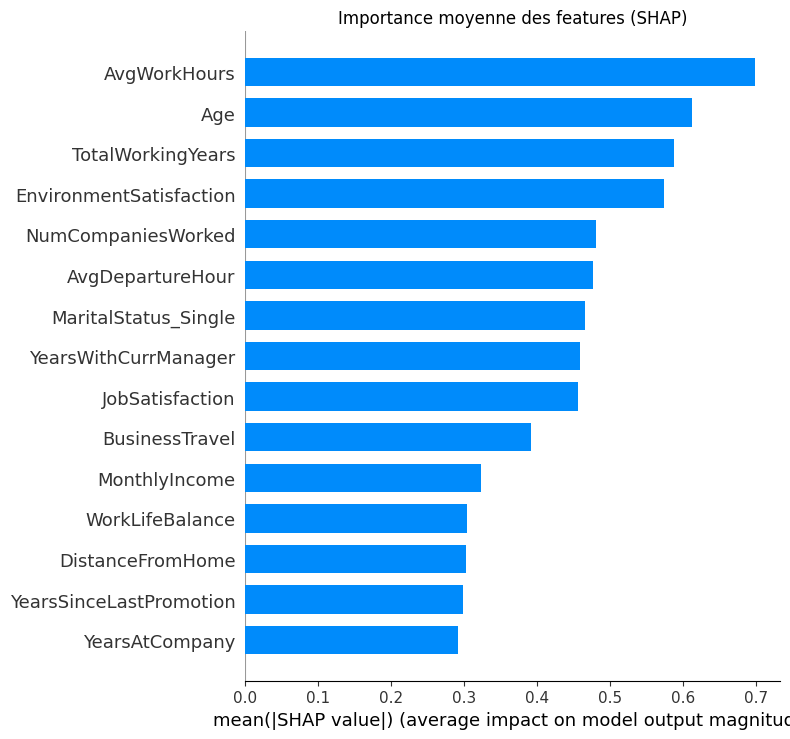

In [44]:
# ─── SHAP Bar Plot (importance moyenne absolue) ──────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test, plot_type="bar", max_display=15, show=False)
plt.title("Importance moyenne des features (SHAP)")
plt.tight_layout()
plt.show()

## 9. Analyse du seuil de décision

Par défaut, le seuil est de **0.5**. En contexte RH :
- **Seuil bas (ex: 0.3)** → détecte plus d'employés à risque (meilleur recall) — si le coût d'un départ imprévu est élevé
- **Seuil haut (ex: 0.7)** → moins de fausses alertes (meilleure precision) — si les actions de rétention sont coûteuses

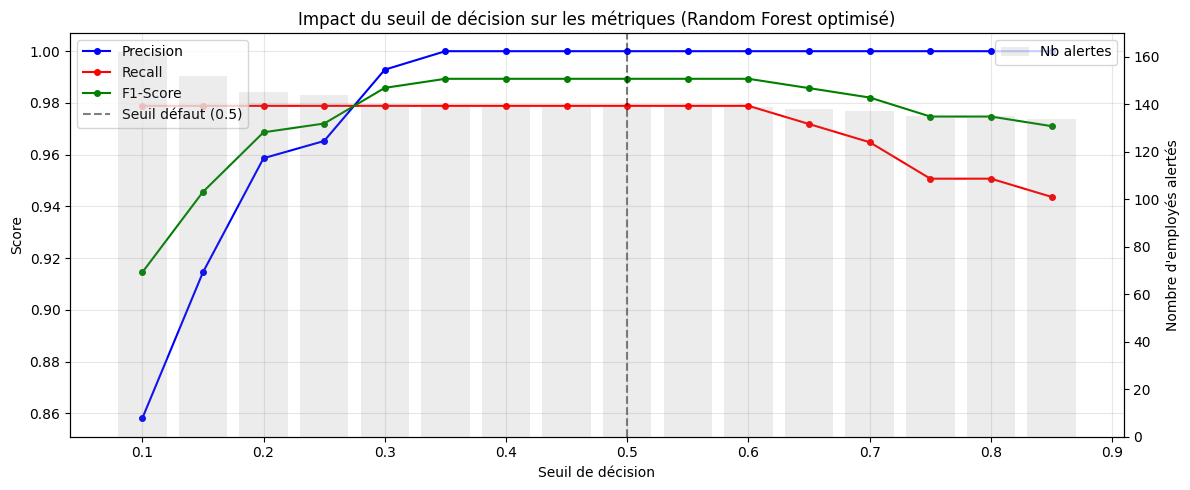


✓ Seuil optimal (F1 max) : 0.35
  Precision : 1.000 | Recall : 0.979 | F1 : 0.989
  Nombre d'employés alertés : 139


In [45]:
# ─── Impact du seuil sur les métriques ────────────────────────────────────────
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    threshold_results.append({
        "Seuil":     t,
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall":    recall_score(y_test, y_pred_t),
        "F1":        f1_score(y_test, y_pred_t, zero_division=0),
        "N_alertes": y_pred_t.sum()
    })

thr_df = pd.DataFrame(threshold_results)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(thr_df["Seuil"], thr_df["Precision"], 'b-o', markersize=4, label="Precision")
ax1.plot(thr_df["Seuil"], thr_df["Recall"],    'r-o', markersize=4, label="Recall")
ax1.plot(thr_df["Seuil"], thr_df["F1"],        'g-o', markersize=4, label="F1-Score")
ax1.axvline(0.5, color='k', linestyle='--', alpha=0.5, label="Seuil défaut (0.5)")
ax2.bar(thr_df["Seuil"], thr_df["N_alertes"], alpha=0.15, color='gray', width=0.04, label="Nb alertes")

ax1.set_xlabel("Seuil de décision")
ax1.set_ylabel("Score")
ax2.set_ylabel("Nombre d'employés alertés")
ax1.set_title("Impact du seuil de décision sur les métriques (Random Forest optimisé)")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Seuil optimal selon F1
best_t = thr_df.loc[thr_df["F1"].idxmax()]
print(f"\n✓ Seuil optimal (F1 max) : {best_t['Seuil']:.2f}")
print(f"  Precision : {best_t['Precision']:.3f} | Recall : {best_t['Recall']:.3f} | F1 : {best_t['F1']:.3f}")
print(f"  Nombre d'employés alertés : {int(best_t['N_alertes'])}")

## 10. Recommandations actionnables pour HumanForYou

Au-delà des métriques, l'objectif est de fournir au client des **pistes concrètes et chiffrées** pour réduire le taux d'attrition.

In [46]:
# ─── Analyse des profils à risque avec le modèle retenu ───────────────────────
# On identifie les segments d'employés les plus à risque

# Reconstruire un df avec les prédictions
df_analysis = X_test.copy()
df_analysis['proba_attrition'] = y_proba_best
df_analysis['attrition_reelle'] = y_test.values

# Identifier les features les plus importantes via SHAP
mean_shap = np.abs(shap_vals).mean(axis=0)
top_features_shap = pd.Series(mean_shap, index=X_test.columns).sort_values(ascending=False).head(10)
print("Top 10 features par importance SHAP :")
print(top_features_shap.round(4).to_string())
print()

# ─── Segmentation des profils à risque ────────────────────────────────────────
high_risk = df_analysis[df_analysis['proba_attrition'] >= 0.5]
low_risk  = df_analysis[df_analysis['proba_attrition'] < 0.3]

print(f"Employés à risque élevé (proba ≥ 0.5) : {len(high_risk)} ({len(high_risk)/len(df_analysis):.1%})")
print(f"Employés à risque faible (proba < 0.3) : {len(low_risk)} ({len(low_risk)/len(df_analysis):.1%})")
print()

# Comparer les caractéristiques clés entre les deux groupes
key_features = ['AvgWorkHours', 'JobSatisfaction', 'MonthlyIncome', 
                'YearsAtCompany', 'DistanceFromHome', 'AvgArrivalHour',
                'TotalWorkingYears', 'EnvironmentSatisfaction']
key_features = [f for f in key_features if f in df_analysis.columns]

comparison = pd.DataFrame({
    'Risque élevé (≥0.5)': high_risk[key_features].mean(),
    'Risque faible (<0.3)': low_risk[key_features].mean(),
})
comparison['Écart (%)'] = ((comparison.iloc[:, 0] - comparison.iloc[:, 1]) / comparison.iloc[:, 1].abs().clip(lower=0.01) * 100).round(1)

print("Comparaison des profils à risque vs profils stables :")
print(comparison.round(3).to_string())

Top 10 features par importance SHAP :
AvgWorkHours               0.6976
Age                        0.6114
TotalWorkingYears          0.5877
EnvironmentSatisfaction    0.5734
NumCompaniesWorked         0.4808
AvgDepartureHour           0.4763
MaritalStatus_Single       0.4649
YearsWithCurrManager       0.4585
JobSatisfaction            0.4553
BusinessTravel             0.3917

Employés à risque élevé (proba ≥ 0.5) : 139 (15.8%)
Employés à risque faible (proba < 0.3) : 742 (84.1%)

Comparaison des profils à risque vs profils stables :
                         Risque élevé (≥0.5)  Risque faible (<0.3)  Écart (%)
AvgWorkHours                           0.419                -0.087      580.3
JobSatisfaction                       -0.094                 0.130     -172.9
MonthlyIncome                         -0.131                 0.046     -384.9
YearsAtCompany                        -0.124                 0.099     -224.7
DistanceFromHome                      -0.078                -0.057     

In [47]:
# ─── Règles métier actionnables ────────────────────────────────────────────────
print("=" * 65)
print("   RECOMMANDATIONS ACTIONNABLES POUR HUMANFORYOU")
print("=" * 65)

# Analyser les seuils critiques sur les features clés
for feat in ['JobSatisfaction', 'EnvironmentSatisfaction', 'MonthlyIncome', 'YearsAtCompany']:
    if feat not in df_analysis.columns:
        continue
    median_val = df_analysis[feat].median()
    
    below = df_analysis[df_analysis[feat] <= median_val]
    above = df_analysis[df_analysis[feat] > median_val]
    
    risk_below = below['proba_attrition'].mean()
    risk_above = above['proba_attrition'].mean()
    ratio = risk_below / max(risk_above, 0.001)
    
    print(f"\n▸ {feat} :")
    print(f"  - {feat} ≤ médiane : risque moyen = {risk_below:.1%}")
    print(f"  - {feat} > médiane : risque moyen = {risk_above:.1%}")
    print(f"  → Les employés sous la médiane ont {ratio:.1f}× plus de risque d'attrition")

print("\n" + "=" * 65)
print("\nPistes d'action prioritaires pour la direction :")
print("1. Monitorer les employés avec satisfaction faible (Job & Environment ≤ 2)")
print("2. Revoir la politique salariale pour les profils à faible revenu + forte ancienneté")
print("3. Mettre en place des entretiens préventifs pour les profils détectés à risque > 50%")
print("4. Surveiller les employés dont les heures de travail augmentent (WorkHoursTrend > 0)")
print("5. Réduire le turnover managers : la stabilité managériale réduit l'attrition")

   RECOMMANDATIONS ACTIONNABLES POUR HUMANFORYOU

▸ JobSatisfaction :
  - JobSatisfaction ≤ médiane : risque moyen = 18.6%
  - JobSatisfaction > médiane : risque moyen = 12.9%
  → Les employés sous la médiane ont 1.4× plus de risque d'attrition

▸ EnvironmentSatisfaction :
  - EnvironmentSatisfaction ≤ médiane : risque moyen = 18.3%
  - EnvironmentSatisfaction > médiane : risque moyen = 13.4%
  → Les employés sous la médiane ont 1.4× plus de risque d'attrition

▸ MonthlyIncome :
  - MonthlyIncome ≤ médiane : risque moyen = 17.8%
  - MonthlyIncome > médiane : risque moyen = 15.7%
  → Les employés sous la médiane ont 1.1× plus de risque d'attrition

▸ YearsAtCompany :
  - YearsAtCompany ≤ médiane : risque moyen = 20.5%
  - YearsAtCompany > médiane : risque moyen = 12.7%
  → Les employés sous la médiane ont 1.6× plus de risque d'attrition


Pistes d'action prioritaires pour la direction :
1. Monitorer les employés avec satisfaction faible (Job & Environment ≤ 2)
2. Revoir la politique sal

## 11. Synthèse finale

### Modèle retenu et justification

Le modèle **XGBoost optimisé** (ou RF optimisé selon les résultats) est retenu pour sa combinaison :
- **Meilleure AUC-ROC** en validation croisée → meilleure capacité de discrimination
- **Interprétabilité via SHAP** → les décisions sont explicables au client
- **Robustesse** → régularisation native et validation croisée stratifiée

### Bilan méthodologique

| Aspect | Approche retenue |
|--------|-----------------|
| Données manquantes | Imputation médiane/mode + flags binaires pour l'enquête (non-réponse informative) |
| Outliers | Winsorization ciblée + conservation des valeurs métier cohérentes |
| Déséquilibre | class_weight balanced + comparaison avec SMOTE |
| Fuite de données | Scaler fitté uniquement sur le train |
| Optimisation | RandomizedSearchCV (50 itérations) sur XGBoost + GridSearch RF |
| Interprétabilité | SHAP values (vs. Gini importance biaisé) |
| Modèles | 4 modèles : Random Forest, Rég. Logistique, XGBoost, RF+SMOTE |

### Limites et perspectives

- **Données temporelles** : l'analyse de tendance est linéaire — un modèle de séries temporelles pourrait capter des patterns plus fins
- **Données d'enquête** : le taux de non-réponse est potentiellement corrélé à l'attrition — une étude dédiée (analyse de survie) enrichirait l'analyse
- **Déploiement** : en production, le modèle devrait être revalidé régulièrement et les seuils ajustés selon le feedback RH